SEMANA 5: LOGISTIC REGRESSION

LOGISTIC REGRESSION vs LINEAR REGRESSION

Linear Regression:        Logistic Regression:
y = w*x + b              y = σ(w*x + b)
Continuo [−∞, +∞]       Probabilidad [0, 1]
Regresión               Clasificación

¿QUÉ ES SIGMOID?
σ(z) = 1 / (1 + e^(-z))

Propiedades:
- σ(0) = 0.5
- σ(z > 0) > 0.5
- σ(z < 0) < 0.5
- σ(−z) = 1 − σ(z)

APLICACIÓN: Clasificación binaria (0/1)
- y = 1 si σ(w*x + b) > 0.5
- y = 0 si σ(w*x + b) < 0.5

LOSS FUNCTION: Cross-Entropy
L = −[y*log(ŷ) + (1−y)*log(1−ŷ)]



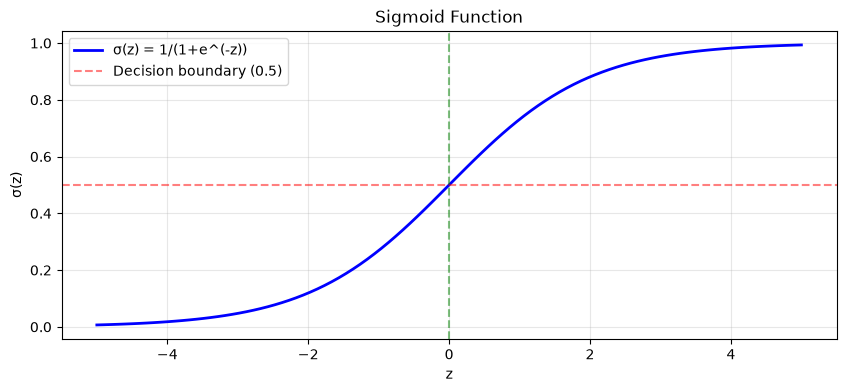

✅ Sigmoid visualizado


In [1]:
# 🔹 Celda 1: Introducción

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.special import expit  # Sigmoid function

print("=" * 60)
print("SEMANA 5: LOGISTIC REGRESSION")
print("=" * 60)

print("""
LOGISTIC REGRESSION vs LINEAR REGRESSION

Linear Regression:        Logistic Regression:
y = w*x + b              y = σ(w*x + b)
Continuo [−∞, +∞]       Probabilidad [0, 1]
Regresión               Clasificación

¿QUÉ ES SIGMOID?
σ(z) = 1 / (1 + e^(-z))

Propiedades:
- σ(0) = 0.5
- σ(z > 0) > 0.5
- σ(z < 0) < 0.5
- σ(−z) = 1 − σ(z)

APLICACIÓN: Clasificación binaria (0/1)
- y = 1 si σ(w*x + b) > 0.5
- y = 0 si σ(w*x + b) < 0.5

LOSS FUNCTION: Cross-Entropy
L = −[y*log(ŷ) + (1−y)*log(1−ŷ)]
""")

# Visualizar sigmoid
z = np.linspace(-5, 5, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 4))
plt.plot(z, sigmoid, 'b-', linewidth=2, label='σ(z) = 1/(1+e^(-z))')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Decision boundary (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Sigmoid visualizado")



DATASET: CLASIFICACIÓN BINARIA
Dataset: 200 samples, 2 features
Clase 0: 100 samples
Clase 1: 100 samples


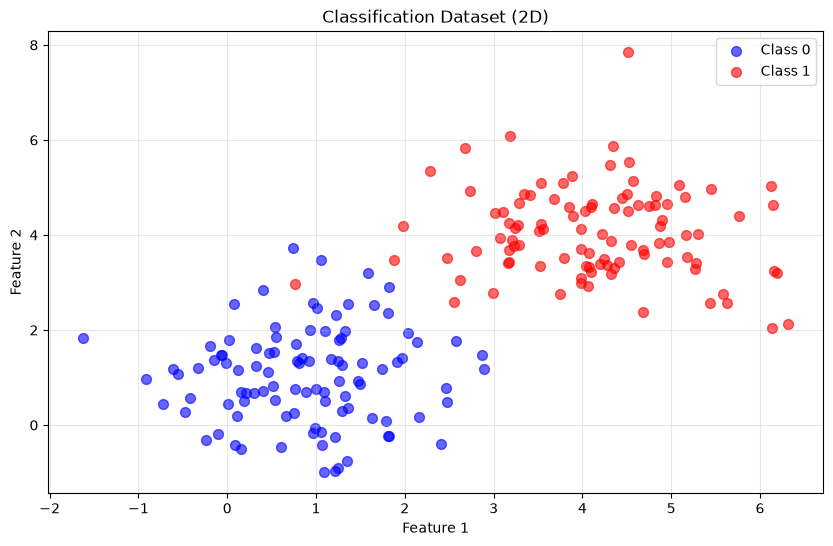

✅ Dataset creado


In [2]:
# 🔹 Celda 2: Dataset Clasificación

print("\n" + "=" * 60)
print("DATASET: CLASIFICACIÓN BINARIA")
print("=" * 60)

# Generar dataset de clasificación 2D
np.random.seed(42)
n_samples = 200

# Clase 0 (cluster1)
x0 = np.random.randn(n_samples // 2, 2) + np.array([1, 1])
y0 = np.zeros(n_samples // 2)

# Clase 1 (cluster2)
x1 = np.random.randn(n_samples // 2, 2) + np.array([4, 4])
y1 = np.ones(n_samples // 2)

# Combinar
X = np.vstack([x0, x1])
y = np.hstack([y0, y1])

# Mezclar
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y = y[shuffle_idx]

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Clase 0: {np.sum(y == 0)} samples")
print(f"Clase 1: {np.sum(y == 1)} samples")

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.6, s=50, label='Class 0', c='blue')
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.6, s=50, label='Class 1', c='red')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Classification Dataset (2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ Dataset creado")


In [3]:
# 🔹 Celda 3: Logistic Regression desde Cero

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION DESDE CERO")
print("=" * 60)

class LogisticRegressionManual:
    """Logistic Regression con Gradient Descent"""
    
    def __init__(self, learning_rate=0.01, iterations=1000, verbose=False):
        self.lr = learning_rate
        self.iterations = iterations
        self.verbose = verbose
        self.w = None
        self.b = None
        self.history = {'loss': []}
    
    def sigmoid(self, z):
        """σ(z) = 1 / (1 + e^(-z))"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip para evitar overflow
    
    def cross_entropy_loss(self, y_true, y_pred):
        """L = −[y*log(ŷ) + (1−y)*log(1−ŷ)]"""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        """Entrenar"""
        n_samples, n_features = X.shape
        
        # Inicializar
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        if self.verbose:
            print(f"Training: {n_samples} samples, {n_features} features")
        
        for i in range(self.iterations):
            # Forward pass
            z = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(z)
            
            # Loss
            loss = self.cross_entropy_loss(y, y_pred)
            self.history['loss'].append(loss)
            
            # Gradientes
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)
            
            # Actualizar
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db
            
            if self.verbose and (i + 1) % 200 == 0:
                print(f"Iter {i+1}: Loss={loss:.4f}")
        
        if self.verbose:
            print(f"✅ Training complete! Final loss={loss:.4f}")
    
    def predict_proba(self, X):
        """Probabilidades"""
        z = np.dot(X, self.w) + self.b
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """Predicciones (0/1)"""
        return (self.predict_proba(X) > threshold).astype(int)

# Entrenar
model = LogisticRegressionManual(learning_rate=0.1, iterations=1000, verbose=True)
model.fit(X, y)

# Predicciones
y_pred_proba = model.predict_proba(X)
y_pred = model.predict(X)

print(f"\nAccuracy: {accuracy_score(y, y_pred):.4f}")



LOGISTIC REGRESSION DESDE CERO
Training: 200 samples, 2 features
Iter 200: Loss=0.2042
Iter 400: Loss=0.1374
Iter 600: Loss=0.1097
Iter 800: Loss=0.0943
Iter 1000: Loss=0.0844
✅ Training complete! Final loss=0.0844

Accuracy: 0.9950



DECISION BOUNDARY


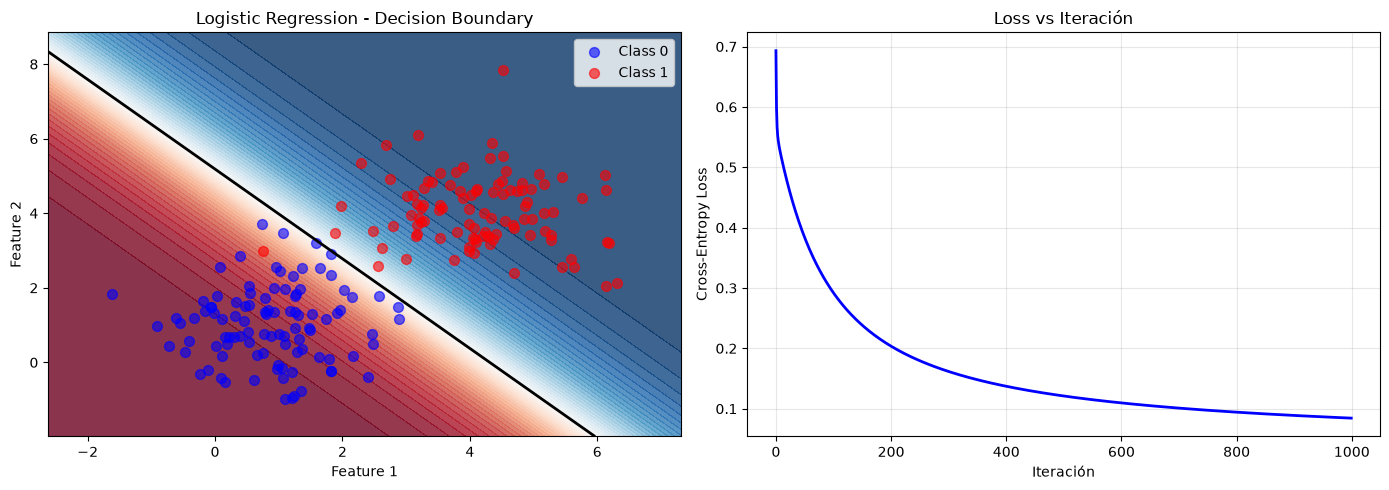

✅ Decision boundary visualizado


In [4]:
# 🔹 Celda 4: Visualizar Decision Boundary

print("\n" + "=" * 60)
print("DECISION BOUNDARY")
print("=" * 60)

# Crear mesh para visualizar
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary
ax1.contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.8)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
ax1.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.6, s=50, c='blue', label='Class 0')
ax1.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.6, s=50, c='red', label='Class 1')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_title('Logistic Regression - Decision Boundary')
ax1.legend()

# Loss curve
ax2.plot(model.history['loss'], 'b-', linewidth=2)
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_title('Loss vs Iteración')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Decision boundary visualizado")


In [5]:
# 🔹 Celda 5: Comparar con sklearn

print("\n" + "=" * 60)
print("COMPARAR CON SKLEARN")
print("=" * 60)

# Entrenar sklearn
model_sklearn = LogisticRegression(max_iter=1000)
model_sklearn.fit(X, y)
y_pred_sklearn = model_sklearn.predict(X)

# Comparar
acc_manual = accuracy_score(y, y_pred)
acc_sklearn = accuracy_score(y, y_pred_sklearn)

print(f"\n📊 COMPARACIÓN:")
print(f"Manual:  Accuracy={acc_manual:.4f}")
print(f"Sklearn: Accuracy={acc_sklearn:.4f}")

# Matriz de confusión (Manual)
cm_manual = confusion_matrix(y, y_pred)
print(f"\nMatriz de confusión (Manual):")
print(cm_manual)

# Matriz de confusión (Sklearn)
cm_sklearn = confusion_matrix(y, y_pred_sklearn)
print(f"\nMatriz de confusión (Sklearn):")
print(cm_sklearn)

# Report
print(f"\nClassification Report (Manual):")
print(classification_report(y, y_pred))



COMPARAR CON SKLEARN

📊 COMPARACIÓN:
Manual:  Accuracy=0.9950
Sklearn: Accuracy=0.9950

Matriz de confusión (Manual):
[[100   0]
 [  1  99]]

Matriz de confusión (Sklearn):
[[100   0]
 [  1  99]]

Classification Report (Manual):
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       100
         1.0       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200




EFECTO DEL THRESHOLD


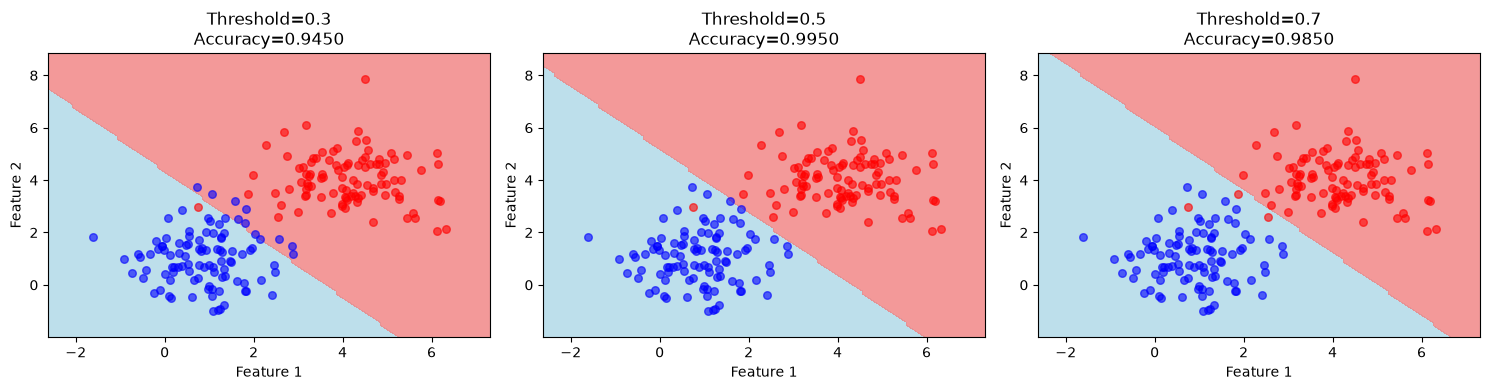


💡 OBSERVACIÓN:
- Threshold bajo (0.3): Predice más 1s (recall alto)
- Threshold medio (0.5): Balance (default)
- Threshold alto (0.7): Predice más 0s (precision alto)


In [6]:
# 🔹 Celda 6: Probabilidades y Threshold

print("\n" + "=" * 60)
print("EFECTO DEL THRESHOLD")
print("=" * 60)

thresholds = [0.3, 0.5, 0.7]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, th in enumerate(thresholds):
    y_pred_th = model.predict(X, threshold=th)
    acc = accuracy_score(y, y_pred_th)
    
    ax = axes[idx]
    # Decision boundary
    Z_th = (model.predict_proba(np.c_[xx.ravel(), yy.ravel()]) > th).astype(int)
    Z_th = Z_th.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z_th, levels=1, colors=['lightblue', 'lightcoral'], alpha=0.8)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.6, s=30, c='blue')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.6, s=30, c='red')
    ax.set_title(f'Threshold={th}\nAccuracy={acc:.4f}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

print("\n💡 OBSERVACIÓN:")
print("- Threshold bajo (0.3): Predice más 1s (recall alto)")
print("- Threshold medio (0.5): Balance (default)")
print("- Threshold alto (0.7): Predice más 0s (precision alto)")
